# Prototype: which experiment to run next

One coherence signal has been measured and fitted, and the posterior still
holds several explanations of it. Given a list of experiments that could be
run next, each a different pulse number on a grid of delays, this notebook
works out which one to run and at which delays:

1. **Simulate every hypothesis.** The posterior is reduced to a weighted set
   of distinct baths, and each candidate experiment is simulated for all of
   them.
2. **Find where they disagree.** At each delay, the weighted variance of the
   simulated signals says how much a measurement there could tell the baths
   apart.
3. **Charge for time.** One repetition of a sequence with $N$ pulses at
   delay $\tau$ takes $2N\tau$. Every candidate gets the same total time,
   so a slow point is measured fewer times and is noisier.
4. **Choose pulse number and delays together.** Each candidate is given its
   own best set of delays, and the candidates are then compared by the
   expected information gain of those designs.
5. **Say so when nothing would help.** If the best design on the list gains
   less than a set threshold, the answer is that no experiment on the list
   can tell the baths apart, and no experiment is returned.

**The output is one experiment**: a pulse number and the delays to measure
at, with how the measurement time is to be shared between them. Section 6
prints it as a table to hand to whoever runs the measurement.

This is a standalone prototype. The design logic in section 4 is written
here from scratch and does not use the package's `ExperimentDesigner`. The
package supplies the forward model, the sampler that produces the posterior,
and the grouping of posterior draws into baths.

In [1]:
import collections
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display
from scipy.special import logsumexp

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO / "src") not in sys.path:
    sys.path.insert(0, str(REPO / "src"))

from nuclear_spin_recovery import (
    RJMCMC,
    RWMH,
    AnalyticCCE1,
    BirthDeathKernel,
    DiscreteLatticeWalk,
    Experiment,
    ExperimentSet,
    GaussianL2,
    HybridDriver,
    NeighborIndex,
    ParameterBlock,
    ParticleSet,
    Schedule,
    SiteScaledOffset,
    SiteTable,
    State,
    Step,
    StretchedExponential,
    Target,
    Trace,
    gyromagnetic_ratio,
    merge_traces,
    simulate_dataset,
)
from nuclear_spin_recovery.post import predictive_from_arrays

# One colour per pulse number, in a fixed order, used in every figure.
PULSE_COLOURS = {4: "#2a78d6", 8: "#eb6834", 16: "#1baf7a", 32: "#eda100",
                 64: "#e87ba4"}
C_BEFORE, C_AFTER = "#898781", "#2a78d6"
C_INK, C_MUTED, C_GRID, C_AXIS = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"
C_SOFT = "#f0efec"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": C_AXIS, "axes.labelcolor": "#52514e",
    "xtick.color": C_MUTED, "ytick.color": C_MUTED,
    "grid.color": C_GRID, "grid.linewidth": 0.6, "legend.frameon": False,
    "figure.dpi": 110,
})

## 1. The system and the first measurement

The ten-site toy lattice of the relaxation notebooks, with three true spins
that each sit away from their table value, measured once with CPMG-4.

Unlike those notebooks, the signal here **decays**. Without decoherence a
sequence with more pulses always wins: its dips deepen faster than its
duration grows, and the question of which pulse number to use has no
content. The decay is a plain exponential in $\tau$. Its constant at four
pulses, $\lambda_4$, is set to **ten periods of the signal**: the dips
repeat every half Larmor period in $\tau$, 1.5 µs at this field, so
$\lambda_4$ = 15 µs and the modulation is still visible ten dips in. At
another pulse number

$$\lambda_N = \lambda_4\,(N/4)^{\gamma-1}.$$

This is the usual model in which the coherence time in *total* evolution
time grows as $N^\gamma$. **$\gamma$ is an assumption about the sample**, set
here to 2/3, and the design depends on it: it decides how quickly the longer
sequences lose their signal.

In [2]:
CENTRES = np.array([
    (100.0, 100.0), (10.0, 10.0), (100.0, 50.0), (60.0, 80.0), (150.0, 60.0),
    (40.0, 30.0), (75.0, 120.0), (130.0, 110.0), (25.0, 60.0), (55.0, 45.0)])
N_SITES, K_MAX = len(CENTRES), 6
TRUE = {2: (5.0, 2.0), 3: (-4.0, 5.0), 7: (8.0, -6.0)}   # site -> offset, kHz
TRUE_SITES = tuple(sorted(TRUE))
FRACTION = 0.10            # each coupling may relax by ±10% of its table value

B_Z = 311.0                # G
# The signal repeats in tau every half Larmor period, pi / omega_L.
SIGNAL_PERIOD = np.pi / (gyromagnetic_ratio("13C") * B_Z)      # ms
DECAY_PERIODS = 10         # the decay constant, in periods of the signal
LAMBDA_4 = DECAY_PERIODS * SIGNAL_PERIOD     # ms, in tau, at four pulses
GAMMA = 2.0 / 3.0          # coherence time grows as N ** GAMMA  (an assumption)
DATA_NOISE = 0.002         # noise of one point at unit measurement weight
LIK_SIGMA = 0.02           # the repo's calibrated likelihood width

_angle = np.linspace(0.0, 2.0 * np.pi, N_SITES, endpoint=False)
POSITIONS = np.column_stack([2.0 * np.cos(_angle), 2.0 * np.sin(_angle),
                             np.full(N_SITES, 2.0)])
table = SiteTable(
    distance=np.linalg.norm(POSITIONS, axis=1), positions=POSITIONS,
    a_par=CENTRES[:, 0], a_perp=CENTRES[:, 1],
    isotope=np.array(["13C"] * N_SITES),
    gyro=np.full(N_SITES, gyromagnetic_ratio("13C")))
model = AnalyticCCE1(StretchedExponential())


def decay_constant(n_pulses):
    """lambda at ``n_pulses``, scaled from the measured four-pulse value."""
    return LAMBDA_4 * (n_pulses / 4.0) ** (GAMMA - 1.0)


def make_state(sites, offsets=None, n_pulses=4):
    state = State.from_sites(
        tuple(int(s) for s in sites), n_sites=N_SITES, n_exp=1,
        lam=np.full((1, 1), decay_constant(n_pulses)),
        n_stretch=np.ones((1, 1)), sigma=np.full((1, 1), LIK_SIGMA),
        k_max=K_MAX, site_memory=True)
    if offsets is not None:
        for slot, (d_par, d_perp) in enumerate(offsets):
            state.set_offset(0, slot, 0, d_par)
            state.set_offset(0, slot, 1, d_perp)
    return state


def truth_state(n_pulses):
    return make_state(TRUE_SITES, [TRUE[s] for s in TRUE_SITES], n_pulses)


print(f"signal period {SIGNAL_PERIOD * 1e3:.2f} µs, decay constant at four "
      f"pulses {LAMBDA_4 * 1e3:.1f} µs")

tau_first = np.linspace(3.2e-5, 8e-3, 250)             # ms
first = ExperimentSet([Experiment(tau=tau_first, n_pulses=4, b_z=B_Z)])
data = simulate_dataset(truth_state(4), first, table, model, sigma=DATA_NOISE,
                        rng=np.random.default_rng(3))
target = Target(data, model, GaussianL2(), table)

signal period 1.50 µs, decay constant at four pulses 15.0 µs


## 2. The posterior

Four chains from different seeds, pooled. Each runs RJMCMC, a site walk and
an offset walk with site memory, as in `toy_rjmcmc_ten_sites`.

The chains are not tempered, and that notebook showed what follows: they
settle on different explanations and do not move between them. Pooled, they
give a spread of hypotheses, which is what a design needs. **The pooled
weights are not posterior probabilities.** A hypothesis that half the chains
found is not thereby half as likely as the truth. For choosing an experiment
to tell the hypotheses apart that matters less than it would for reporting
them, but it is the weakest input to everything below.

In [3]:
N_STEPS, N_BURN, N_CHAINS = 12000, 3000, 4


def run_chain(seed):
    schedule = Schedule([
        Step(RJMCMC(ParameterBlock("sites"), BirthDeathKernel(k_max=K_MAX)), 10),
        Step(RWMH(ParameterBlock("sites"),
                  DiscreteLatticeWalk(NeighborIndex(POSITIONS, 10.0))), 10),
        Step(RWMH(ParameterBlock("offsets"), SiteScaledOffset(
            1.0, table, fraction_par=FRACTION, fraction_perp=FRACTION,
            prior="flat")), 40),
    ])
    trace = Trace(n_sites=N_SITES, k_max=K_MAX, n_exp=1)
    HybridDriver(schedule).run(make_state((0,)), target,
                               np.random.default_rng(seed), N_STEPS, trace=trace)
    return trace.discard_burn_in(N_BURN)


pooled = merge_traces([run_chain(seed) for seed in range(N_CHAINS)])
print(f"{len(pooled)} pooled draws from {N_CHAINS} chains")

36000 pooled draws from 4 chains


## 3. From draws to baths

A design compares hypotheses, so the draws have to be grouped into distinct
baths first. Two draws are the same bath when their spins pair up with both
couplings within a tolerance.

The package's default tolerance is 0.1 kHz, chosen for couplings pinned to
their table values. With relaxation on, a coupling wanders by kilohertz
within one hypothesis, and at 0.1 kHz almost every draw is counted as its
own bath. A looser tolerance is needed; the table shows what each choice
gives.

In [4]:
STRIDE = 20


def site_set(particles, i):
    return tuple(sorted(int(s) for s in particles.site_idx[i, : particles.k[i]]))


print(f"{'tolerance':>10s} {'baths':>7s} {'effective':>10s} {'sets of sites':>14s}")
for tol in (0.1, 1.0, 2.0, 3.0, 5.0):
    trial = ParticleSet.from_trace(pooled, table, stride=STRIDE, tol=tol)
    sets = {site_set(trial, i) for i in range(trial.n_particles)}
    print(f"{tol:8.1f} kHz {trial.n_particles:7d} {trial.effective_size:10.1f} "
          f"{len(sets):14d}")

TOLERANCE = 3.0            # kHz
particles = ParticleSet.from_trace(pooled, table, stride=STRIDE, tol=TOLERANCE)
weights = particles.weight
ENTROPY = float(-np.sum(weights * np.log(weights)))

set_weight = collections.Counter()
for i in range(particles.n_particles):
    set_weight[site_set(particles, i)] += weights[i]
print(f"\nat {TOLERANCE} kHz: {particles.n_particles} baths, entropy "
      f"{ENTROPY:.2f} nats, on {len(set_weight)} sets of sites; the heaviest:")
for sites, share in set_weight.most_common(6):
    tag = "   <- the true set" if sites == TRUE_SITES else ""
    print(f"  {list(sites)!s:18s} {share:5.1%}{tag}")

 tolerance   baths  effective  sets of sites


     0.1 kHz    1725     1661.5              6


     1.0 kHz    1043      760.6              6


     2.0 kHz     301      115.3              6
     3.0 kHz     128       35.1              6
     5.0 kHz      39       13.6              6



at 3.0 kHz: 128 baths, entropy 4.12 nats, on 6 sets of sites; the heaviest:
  [2, 3, 7]          47.4%   <- the true set
  [1, 2, 3, 7]       28.9%
  [2, 3, 7, 9]        8.7%
  [1, 2, 3, 7, 9]     7.8%
  [2, 3, 5, 7]        5.1%
  [1, 2, 3, 5, 7]     2.1%


The number of baths falls with the tolerance but the number of distinct sets
of sites does not: the tolerance merges draws that differ only in how far
their couplings have relaxed. At 3 kHz the baths are still several to a set
of sites, so the design below is asked to tell apart both *which sites* are
occupied and, more finely, *what their couplings are*.

## 4. The design calculation

Everything the method does is in this cell.

**Time.** One repetition at delay $\tau$ of a sequence with $N$ pulses takes
`time_cost` $= 2N\tau$. A point measured with weight $w$ is repeated $w$
times as often as a point of the first experiment, costs $w \cdot 2N\tau$,
and has noise $\sigma/\sqrt{w}$.

**Where the baths disagree.** `bath_variance` is the weighted variance of
the baths' signals at each delay. `information_rate` is that variance in
units of the noise variance, per unit of time.

**Which delays.** `choose_points` shares the time budget over the delays in
proportion to the square root of that rate, and drops any delay whose share
is under a fifth of the largest. The square root spreads the time: with the
rate itself, nearly everything goes to the single best delay.

**How good the design is.** `expected_information_gain` simulates data from
a bath drawn by weight, and asks how much better that bath explains the data
than the set as a whole does, averaged over many draws. It is the mutual
information between *which bath is true* and the data, in nats. The same
simulated baths and noise are used for every candidate, so that candidates
are compared on their designs and not on their luck.

**The answer.** `propose` gives every candidate its own best delays, scores
each design, and returns the best as a single `Experiment`: its pulse
number, its delays, and the weight of each. If even the best gains less
than `min_gain` it returns `None`, the verdict that nothing on the list can
tell the baths apart. The comparison of all the candidates is returned
alongside, for the figures.

In [5]:
def time_cost(n_pulses, tau):
    """Duration of one repetition at each delay: 2 N tau."""
    return 2.0 * n_pulses * np.asarray(tau, dtype=float)


def predict(n_pulses, tau):
    """Signal of every bath for one candidate. (n_baths, n_points)"""
    lam = np.full((particles.n_particles, 1), decay_constant(n_pulses))
    candidate = ExperimentSet([Experiment(tau=tau, n_pulses=n_pulses, b_z=B_Z)])
    return predictive_from_arrays(
        particles.site_idx, particles.k, particles.dA_par, particles.dA_perp,
        lam, particles.n_stretch, particles.sigma, candidate, table, model,
        k_max=particles.k_max)


def bath_variance(signals):
    """Weighted variance of the baths' signals at each delay. (n_points,)"""
    deviation = signals - signals[:1]
    return weights @ (deviation - weights @ deviation) ** 2


def information_rate(signals, cost, noise=DATA_NOISE):
    """Variance across the baths, in noise units, per unit time. (n_points,)"""
    return bath_variance(signals) / noise**2 / cost


def choose_points(signals, cost, budget, power=0.5, prune=0.2):
    """The delays to measure and the weight of each, spending ``budget``."""
    rate = information_rate(signals, cost)
    share = np.where(rate > 0, rate**power, 0.0)
    if not share.any():
        return np.array([], dtype=int), np.array([])
    keep = np.flatnonzero(share >= prune * share.max())
    time_spent = budget * share[keep] / share[keep].sum()
    return keep, time_spent / cost[keep]


def expected_information_gain(signals, point_weight, draws, noise=DATA_NOISE):
    """Mutual information between bath and data for one design, in nats."""
    if signals.shape[1] == 0:
        return 0.0
    truth, eps = draws
    scaled = signals * np.sqrt(point_weight) / noise        # in noise units
    simulated = scaled[truth] + eps[:, : scaled.shape[1]]
    log_like = -0.5 * np.sum(
        (simulated[:, None, :] - scaled[None, :, :]) ** 2, axis=2)
    evidence = logsumexp(np.log(weights)[None, :] + log_like, axis=1)
    return float(np.mean(log_like[np.arange(truth.size), truth] - evidence))


def propose(candidates, budget, min_gain, n_draws=1000, seed=0):
    """Choose a pulse number and its delays together, or decline.

    ``candidates`` is a list of ``(n_pulses, tau)``.  Returns
    ``(experiment, designs)``.  ``experiment`` is the one experiment to run
    next -- an :class:`Experiment` carrying the pulse number, the delays and
    the weight of each -- or None when even the best candidate gains less
    than ``min_gain``.  ``designs`` holds the design worked out for every
    candidate, the chosen one included.
    """
    rng = np.random.default_rng(seed)
    widest = max(len(tau) for _, tau in candidates)
    draws = (rng.choice(particles.n_particles, size=n_draws, p=weights),
             rng.standard_normal((n_draws, widest)))
    designs = []
    for n_pulses, tau in candidates:
        signals = predict(n_pulses, tau)
        cost = time_cost(n_pulses, tau)
        idx, point_weight = choose_points(signals, cost, budget)
        designs.append({
            "n_pulses": n_pulses, "grid": tau, "signals": signals,
            "variance": bath_variance(signals),
            "rate": information_rate(signals, cost),
            "index": idx, "tau": tau[idx], "weight": point_weight,
            "time": point_weight * cost[idx],
            "gain": expected_information_gain(signals[:, idx], point_weight,
                                              draws),
            "chosen": False,
        })
    best = max(designs, key=lambda d: d["gain"])
    if best["gain"] < min_gain:
        return None, designs
    best["chosen"] = True
    experiment = Experiment(tau=best["tau"], n_pulses=best["n_pulses"],
                            b_z=B_Z, sigma=DATA_NOISE, weight=best["weight"])
    return experiment, designs


def report(experiment, designs, min_gain):
    """The comparison of the candidates, and what was decided."""
    print(f"{'pulses':>6s} {'points':>7s} {'delays (µs)':>14s} "
          f"{'gain (nats)':>12s}")
    for d in designs:
        span = (f"{d['tau'].min() * 1e3:.2f} – {d['tau'].max() * 1e3:.2f}"
                if d["tau"].size else "none")
        mark = "   <- chosen" if d["chosen"] else ""
        print(f"{d['n_pulses']:6d} {d['tau'].size:7d} {span:>14s} "
              f"{d['gain']:12.3f}{mark}")
    if experiment is None:
        best = max(d["gain"] for d in designs)
        print(f"\nNo experiment on this list can tell the baths apart: the best "
              f"gains {best:.3f} nats, under the threshold of {min_gain} nats.")
    else:
        print(f"\nRun CPMG-{experiment.n_pulses} at {len(experiment)} delays "
              f"between {experiment.tau.min() * 1e3:.2f} and "
              f"{experiment.tau.max() * 1e3:.2f} µs.")


def chosen_design(designs):
    """The design behind the proposed experiment."""
    return next(d for d in designs if d["chosen"])


def measurement_rows(experiment):
    """One row per delay of ``experiment``, in the order to be read.

    Each row is ``(delay in ns, sequence duration in µs, share of the
    measurement time, share of the repetitions, expected noise)``.  The
    sequence duration is 2 N tau, the free evolution of one repetition.  The
    shares say how to divide whatever total time is available; the noise is
    what the design assumed, at the budget it was worked out for.
    """
    tau = experiment.tau
    duration = time_cost(experiment.n_pulses, tau)
    time_spent = experiment.weight * duration
    return [(t * 1e6, c * 1e3, share, reps, noise) for t, c, share, reps, noise
            in zip(tau, duration, time_spent / time_spent.sum(),
                   experiment.weight / experiment.weight.sum(),
                   experiment.sigma / np.sqrt(experiment.weight), strict=True)]


def measurement_table(experiment, gain=None):
    """The proposed experiment as a table for whoever will run it."""
    rows = measurement_rows(experiment)
    total = float(np.sum(experiment.weight
                         * time_cost(experiment.n_pulses, experiment.tau)))
    facts = [
        ("Sequence", f"CPMG-{experiment.n_pulses}"),
        ("Magnetic field", f"{experiment.b_z:g} G"),
        ("Delays to measure", f"{len(experiment)}"),
        ("Delay range",
         f"{experiment.tau.min() * 1e3:.2f} – {experiment.tau.max() * 1e3:.2f} µs"),
        ("Time budget designed for",
         f"{total / FIRST_TIME:.2%} of the first experiment"),
    ]
    if gain is not None:
        facts.append(("Expected information gain", f"{gain:.2f} nats"))
    cell = "padding:3px 14px;text-align:right;font-variant-numeric:tabular-nums"
    head = "padding:4px 14px;text-align:right;border-bottom:1.5px solid #888"
    body = "".join(
        f"<tr><td style='{cell}'>{i}</td><td style='{cell}'>{t:.0f}</td>"
        f"<td style='{cell}'>{c:.2f}</td><td style='{cell}'>{share:.1%}</td>"
        f"<td style='{cell}'>{reps:.1%}</td><td style='{cell}'>{noise:.3f}</td></tr>"
        for i, (t, c, share, reps, noise) in enumerate(rows, start=1))
    summary = "".join(
        f"<tr><td style='padding:2px 14px 2px 0;color:#666'>{name}</td>"
        f"<td style='padding:2px 0'><b>{value}</b></td></tr>"
        for name, value in facts)
    return HTML(
        "<div style='font-family:sans-serif;font-size:14px'>"
        "<div style='font-size:17px;margin-bottom:6px'><b>Next measurement</b></div>"
        f"<table style='border-collapse:collapse;margin-bottom:10px'>{summary}</table>"
        "<table style='border-collapse:collapse'><thead><tr>"
        f"<th style='{head}'>#</th>"
        f"<th style='{head}'>delay τ (ns)</th>"
        f"<th style='{head}'>sequence duration 2Nτ (µs)</th>"
        f"<th style='{head}'>share of time</th>"
        f"<th style='{head}'>share of repetitions</th>"
        f"<th style='{head}'>expected noise</th>"
        f"</tr></thead><tbody>{body}</tbody></table>"
        "<div style='color:#666;margin-top:8px;max-width:640px'>"
        "τ is the delay before the first π pulse and after the last; "
        "consecutive π pulses are 2τ apart. Divide the available measurement "
        "time between the delays by <i>share of time</i>; because long "
        "sequences take longer per repetition, that gives the repetition "
        "counts in <i>share of repetitions</i>. <i>Expected noise</i> is the "
        "standard deviation of the coherence at each delay for the budget "
        "above, and falls as the square root of any extra time.</div></div>")


def measurement_csv(experiment, path):
    """Write the same table to ``path`` as CSV."""
    header = ("n_pulses,b_z_gauss,delay_tau_ns,sequence_duration_us,"
              "share_of_time,share_of_repetitions,expected_noise")
    lines = [header]
    lines += [f"{experiment.n_pulses},{experiment.b_z:g},{t:.1f},{c:.4f},"
              f"{share:.5f},{reps:.5f},{noise:.5f}"
              for t, c, share, reps, noise in measurement_rows(experiment)]
    Path(path).write_text("\n".join(lines) + "\n")

## 5. Choosing among five pulse numbers

The candidates are CPMG with 4, 8, 16, 32 and 64 pulses, each on the same
grid of 320 delays out to 16 µs, twice as far as the first experiment
reached. With the decay this slow there is signal out there to use.

**The budget** is a total time. The first experiment took
$\sum_j 2 \cdot 4 \cdot \tau_j$ at unit weight, and the budget here is
0.02% of that. It is small on purpose. With the noise this low, a
generous budget lets every candidate tell the baths apart completely, and
they all score the same; section 7 shows where that happens.

**The threshold** is 0.05 nats. For scale, identifying the true bath
outright would gain the entropy of the set, printed above, and the estimate
of a design that gains nothing scatters around zero by a few thousandths.

In [6]:
FIRST_TIME = float(time_cost(4, tau_first).sum())
BUDGET = 2e-4 * FIRST_TIME
MIN_GAIN = 0.05            # nats
grid = np.linspace(0.05e-3, 16e-3, 320)
candidates = [(n, grid) for n in PULSE_COLOURS]

next_experiment, designs = propose(candidates, BUDGET, MIN_GAIN)
print(f"budget: {BUDGET:.4f} ms, {BUDGET / FIRST_TIME:.2%} of the first "
      f"experiment's {FIRST_TIME:.2f} ms\n")
report(next_experiment, designs, MIN_GAIN)

budget: 0.0016 ms, 0.02% of the first experiment's 8.03 ms

pulses  points    delays (µs)  gain (nats)
     4     180   0.45 – 16.00        0.165
     8     100   0.55 – 15.85        0.707
    16      24    0.60 – 9.80        2.706
    32      30   0.60 – 10.25        2.901
    64      20    0.60 – 6.15        3.222   <- chosen

Run CPMG-64 at 20 delays between 0.60 and 6.15 µs.


### The candidate signals and the variance across the baths

Left: what each candidate would measure, according to every bath of the
posterior, one thin line per bath, with the true bath's signal in black.
Right: the weighted variance of those lines at each delay. This is the raw
disagreement between the hypotheses, before any account of what a delay
costs to measure.

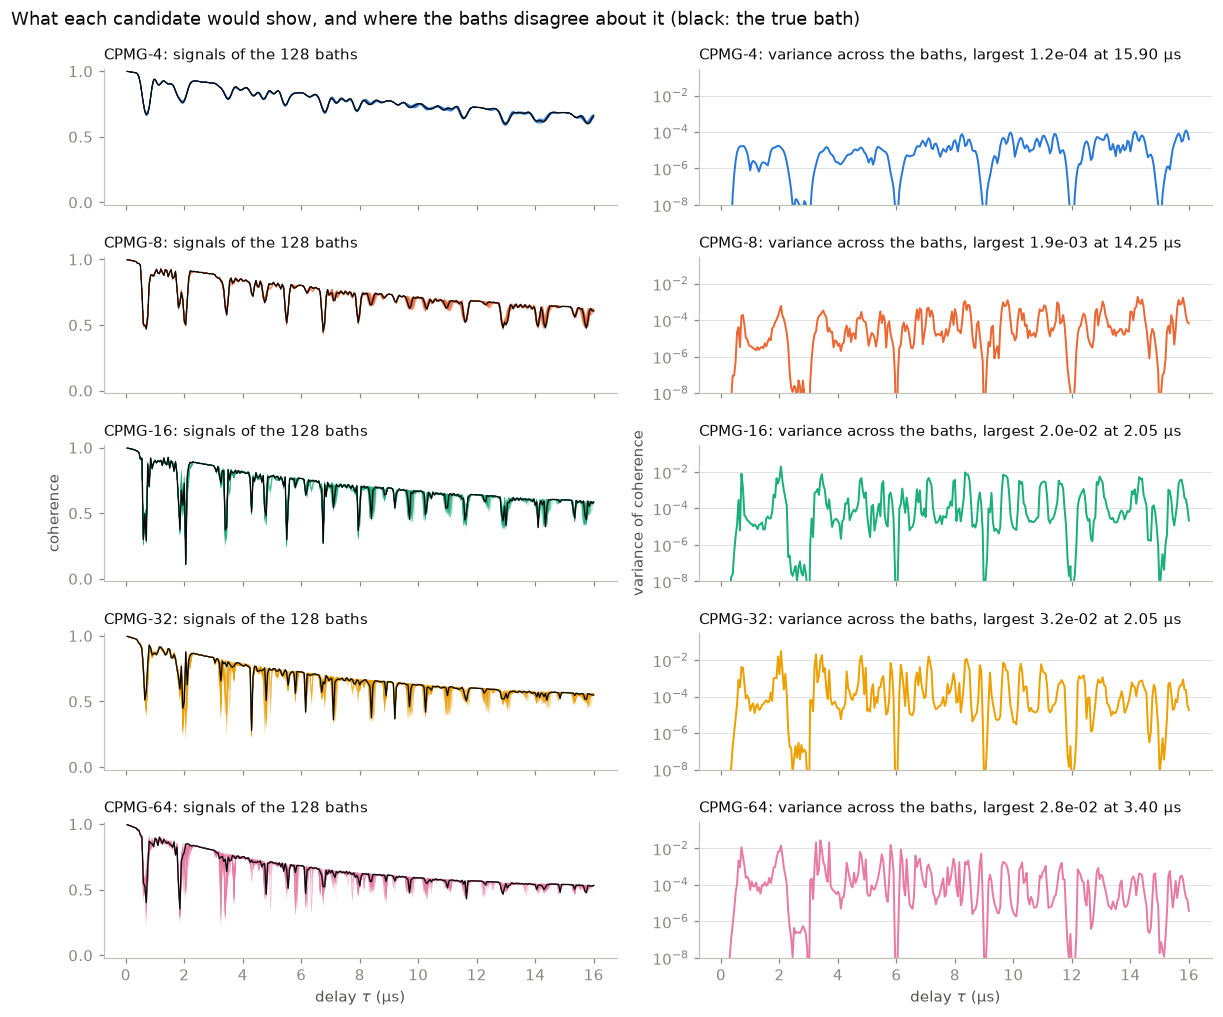

In [7]:
fig, axes = plt.subplots(len(candidates), 2, figsize=(13.0, 10.5), sharex=True,
                         gridspec_kw={"hspace": 0.38, "wspace": 0.16})
for (left, right), d in zip(axes, designs, strict=True):
    n_pulses, colour = d["n_pulses"], PULSE_COLOURS[d["n_pulses"]]
    for i in range(particles.n_particles):
        left.plot(d["grid"] * 1e3, d["signals"][i], color=colour, lw=0.4,
                  alpha=0.12, zorder=1)
    whole = ExperimentSet([Experiment(tau=d["grid"], n_pulses=n_pulses, b_z=B_Z)])
    left.plot(d["grid"] * 1e3,
              model.coherence(truth_state(n_pulses), whole, table)[0],
              color=C_INK, lw=0.9, zorder=2)
    left.set_ylim(-0.02, 1.02)
    left.set_title(f"CPMG-{n_pulses}: signals of the {particles.n_particles} "
                   f"baths", loc="left", fontsize=10, color=C_INK)

    right.plot(d["grid"] * 1e3, d["variance"], color=colour, lw=1.3, zorder=2)
    right.set_yscale("log")
    right.set_ylim(1e-8, 0.3)
    right.grid(axis="y")
    right.set_title(f"CPMG-{n_pulses}: variance across the baths, largest "
                    f"{d['variance'].max():.1e} at "
                    f"{d['grid'][np.argmax(d['variance'])] * 1e3:.2f} µs",
                    loc="left", fontsize=10, color=C_INK)
axes[len(axes) // 2, 0].set_ylabel("coherence")
axes[len(axes) // 2, 1].set_ylabel("variance of coherence")
for ax in axes[-1]:
    ax.set_xlabel(r"delay $\tau$ (µs)")
fig.suptitle("What each candidate would show, and where the baths disagree "
             "about it (black: the true bath)", x=0.06, y=0.93, ha="left",
             color=C_INK)
plt.show()

### The same disagreement, per unit of measurement time

The variance divided by the noise variance and by the $2N\tau$ a repetition
at that delay takes. This is the quantity the delays are chosen on.

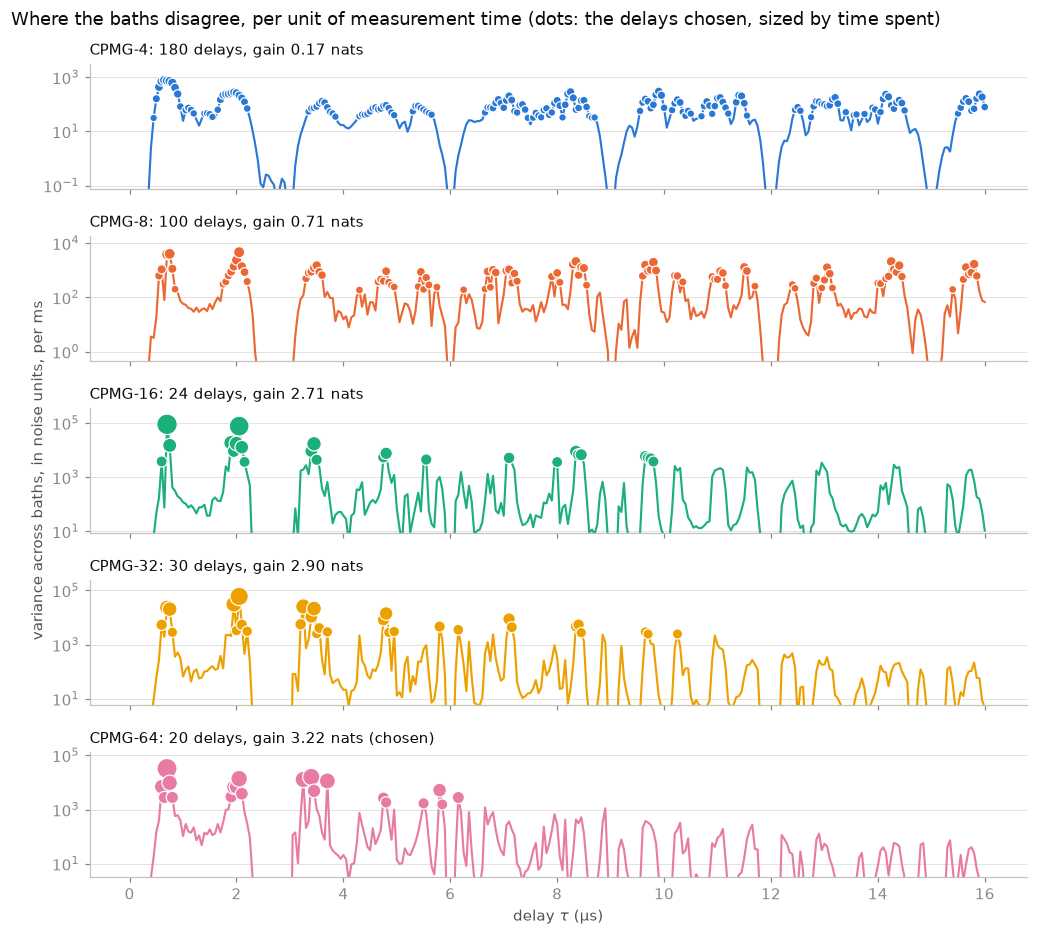

In [8]:
fig, axes = plt.subplots(len(candidates), 1, figsize=(11.0, 9.6), sharex=True,
                         gridspec_kw={"hspace": 0.38})
largest = max(d["time"].max() for d in designs if d["time"].size)
for ax, d in zip(axes, designs, strict=True):
    colour = PULSE_COLOURS[d["n_pulses"]]
    ax.plot(d["grid"] * 1e3, d["rate"], color=colour, lw=1.4, zorder=2)
    ax.scatter(d["tau"] * 1e3, d["rate"][d["index"]],
               s=20 + 160 * d["time"] / largest, color=colour,
               edgecolor="white", linewidths=0.8, zorder=3)
    ax.set_yscale("log")
    ax.set_ylim(max(d["rate"].max() * 1e-4, 1e-3), d["rate"].max() * 4)
    ax.grid(axis="y")
    chosen = " (chosen)" if d["chosen"] else ""
    ax.set_title(f"CPMG-{d['n_pulses']}: {d['tau'].size} delays, gain "
                 f"{d['gain']:.2f} nats{chosen}", loc="left", fontsize=10,
                 color=C_INK)
axes[len(axes) // 2].set_ylabel("variance across baths, in noise units, per ms")
axes[-1].set_xlabel(r"delay $\tau$ (µs)")
fig.suptitle("Where the baths disagree, per unit of measurement time "
             "(dots: the delays chosen, sized by time spent)",
             x=0.06, y=0.93, ha="left", color=C_INK)
plt.show()

Each panel is one candidate. The curve is how much a unit of time at that
delay separates the baths; the dots are the delays its design measures, and
their size is the time each gets. The designs sit on the peaks, where the
hypotheses predict different dips.

## 6. The experiment to run

The output of the whole calculation: one experiment, as a table. Each row
is a delay to measure at. The delays are listed in nanoseconds, with the
free-evolution time of one repetition beside each, and the two share
columns say how to divide the measurement between them.

In [9]:
display(measurement_table(next_experiment, gain=chosen_design(designs)["gain"]))

The same rows are written to `next_experiment.csv`, beside this notebook,
for the instrument or a spreadsheet.

In [10]:
CSV_PATH = (REPO / "notebooks" / "next_experiment.csv")
measurement_csv(next_experiment, CSV_PATH)
print(f"wrote {CSV_PATH.relative_to(REPO)}:\n")
print("\n".join(CSV_PATH.read_text().splitlines()[:6]))
print("...")

wrote notebooks/next_experiment.csv:

n_pulses,b_z_gauss,delay_tau_ns,sequence_duration_us,share_of_time,share_of_repetitions,expected_noise
64,311,600.0,76.8000,0.05292,0.13285,0.06011
64,311,650.0,83.2000,0.03330,0.07715,0.07888
64,311,700.0,89.6000,0.11414,0.24557,0.04421
64,311,750.0,96.0000,0.06213,0.12476,0.06203
64,311,800.0,102.4000,0.03344,0.06296,0.08732
...


The proposal is also an `Experiment` object of the package, so once it has
been measured the data can be attached to it and the pair of experiments
fitted together.

## 7. How the gain depends on the budget

A budget can be counted in two ways, and they rank the candidates
differently.

- **In repetitions.** Each candidate is given a multiple of *its own*
  experiment time, the time one pass over its whole grid takes at unit
  weight. Equal multiples mean equal numbers of repetitions. A pass of
  CPMG-64 takes sixteen times as long as a pass of CPMG-4, so on this
  footing the longer sequences are handed more time and are not charged for
  it.
- **In time.** Every candidate is plotted against the measurement time it
  actually uses, in milliseconds. A longer sequence is now always more
  expensive: the same number of repetitions puts it further to the right.

Both panels below are the same designs and the same gains. Only the
horizontal axis differs.

pulses   one pass over the grid   relative to CPMG-4
     4                 20.54 ms                   1x
     8                 41.09 ms                   2x
    16                 82.18 ms                   4x
    32                164.35 ms                   8x
    64                328.70 ms                  16x


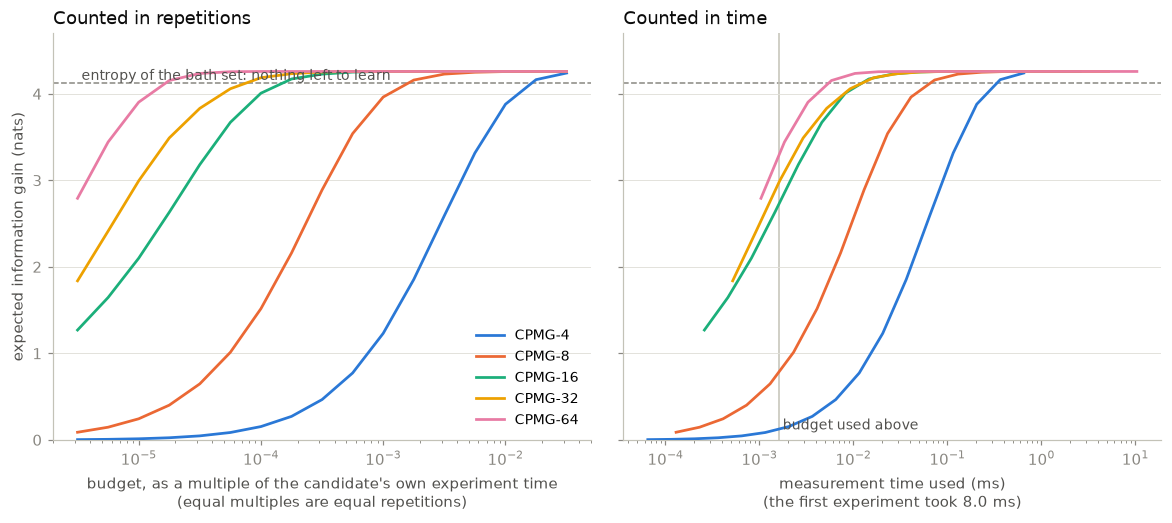

In [11]:
grid_time = {n: float(time_cost(n, grid).sum()) for n in PULSE_COLOURS}
print(f"{'pulses':>6s} {'one pass over the grid':>24s} {'relative to CPMG-4':>20s}")
for n, t in grid_time.items():
    print(f"{n:6d} {t:21.2f} ms {t / grid_time[4]:19.0f}x")

multiples = np.logspace(-5.5, -1.5, 17)
gain_curves = {n: [] for n in PULSE_COLOURS}
for n in PULSE_COLOURS:
    for multiple in multiples:
        _, one = propose([(n, grid)], multiple * grid_time[n], MIN_GAIN,
                         n_draws=400)
        gain_curves[n].append(one[0]["gain"])

fig, (by_reps, by_time) = plt.subplots(1, 2, figsize=(13.0, 4.8), sharey=True,
                                       gridspec_kw={"wspace": 0.06})
for ax in (by_reps, by_time):
    ax.axhline(ENTROPY, color=C_MUTED, lw=1.0, ls="--", zorder=1)
    ax.set_xscale("log")
    ax.grid(axis="y")
for n, gains in gain_curves.items():
    by_reps.plot(multiples, gains, color=PULSE_COLOURS[n], lw=1.8, zorder=3,
                 label=f"CPMG-{n}")
    by_time.plot(multiples * grid_time[n], gains, color=PULSE_COLOURS[n],
                 lw=1.8, zorder=3)
by_reps.text(multiples[0], ENTROPY, " entropy of the bath set: nothing left "
             "to learn", va="bottom", fontsize=9, color="#52514e")
by_time.axvline(BUDGET, color=C_AXIS, lw=1.0, zorder=1)
by_time.text(BUDGET, 0.12, " budget used above", fontsize=9, color="#52514e")
by_reps.set_ylim(0, ENTROPY * 1.14)
by_reps.set_ylabel("expected information gain (nats)")
by_reps.set_xlabel("budget, as a multiple of the candidate's own experiment "
                   "time\n(equal multiples are equal repetitions)")
by_time.set_xlabel("measurement time used (ms)\n"
                   f"(the first experiment took {FIRST_TIME:.1f} ms)")
by_reps.set_title("Counted in repetitions", loc="left", color=C_INK)
by_time.set_title("Counted in time", loc="left", color=C_INK)
by_reps.legend(loc="lower right", fontsize=9)
plt.show()

Counted in repetitions, more pulses is better without exception: the curves
are ordered by pulse number at every budget. Going from 4 pulses to 8, or
from 8 to 16, reaches the same gain with roughly a tenth of the
repetitions; the further doublings save a factor of two or three. That is
the comparison that flatters long sequences, because the time they take is
not in it.

Counted in time, the long sequences pay for themselves and the curves move
together. CPMG-16, 32 and 64 are now close: 64 is ahead across the range
shown, but by about half a nat at most. CPMG-4 and CPMG-8 remain well
behind: at this decay rate their dips are too shallow for the saving in
time to make up for.

Every curve climbs to the same ceiling, the entropy of the bath set, which
is the gain from identifying the true bath outright. Once the budget is
large enough for several candidates to reach it, the gain no longer
separates them, and the cheapest of them would be the sensible pick; this
prototype does not make that second comparison.

## 8. Running the proposed experiment

A check that the design does what it claims. The chosen experiment is
simulated from the true bath, with the noise its weights imply, and every
bath is reweighted by how well it explains the new data.

Before, the true set of sites holds just under half the weight, and the
rest is on the same three sites with one or two extra spins. After, all of
it is on the true set. That includes ruling out the extra spin on site 1,
the weakly coupled site that the four-pulse data could not decide: sixty-four
pulses with a slow decay resolve a spin that four pulses cannot see.

The entropy does not fall to zero. What remains is spread over baths that
share the true sites and differ in how far their couplings have relaxed.

In [12]:
design = chosen_design(designs)
new_exp = ExperimentSet([Experiment(tau=next_experiment.tau,
                                    n_pulses=next_experiment.n_pulses, b_z=B_Z)])
clean = model.coherence(truth_state(next_experiment.n_pulses), new_exp, table)[0]
point_noise = next_experiment.sigma / np.sqrt(next_experiment.weight)
measured = clean + np.random.default_rng(21).normal(0.0, point_noise)

predicted = design["signals"][:, design["index"]]
log_like = -0.5 * np.sum(((measured - predicted) / point_noise) ** 2, axis=1)
updated = weights * np.exp(log_like - log_like.max())
updated /= updated.sum()

after = collections.Counter()
for i in range(particles.n_particles):
    after[site_set(particles, i)] += updated[i]
entropy_after = float(-np.sum(updated[updated > 0] * np.log(updated[updated > 0])))
print(f"entropy of the bath set: {ENTROPY:.2f} nats before, "
      f"{entropy_after:.2f} after; expected gain was {design['gain']:.2f}")
print(f"\n{'occupied sites':18s} {'before':>8s} {'after':>8s}")
for sites, _ in set_weight.most_common():
    tag = "   <- the true set" if sites == TRUE_SITES else ""
    print(f"{list(sites)!s:18s} {set_weight[sites]:8.1%} "
          f"{after.get(sites, 0.0):8.1%}{tag}")

entropy of the bath set: 4.12 nats before, 0.96 after; expected gain was 3.22

occupied sites       before    after
[2, 3, 7]             47.4%   100.0%   <- the true set
[1, 2, 3, 7]          28.9%     0.0%
[2, 3, 7, 9]           8.7%     0.0%
[1, 2, 3, 7, 9]        7.8%     0.0%
[2, 3, 5, 7]           5.1%     0.0%
[1, 2, 3, 5, 7]        2.1%     0.0%


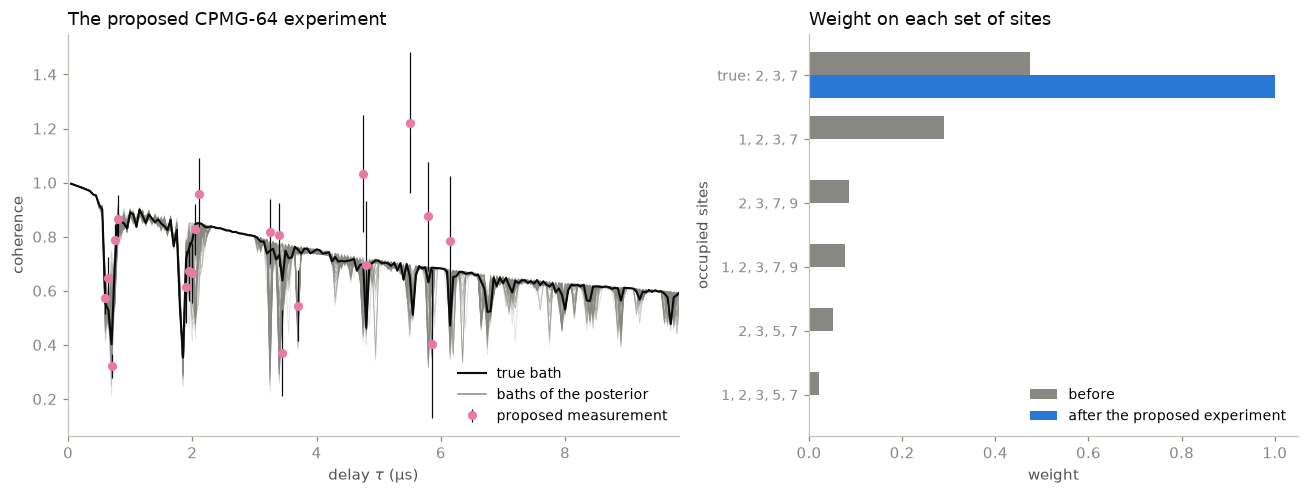

In [13]:
shown = [s for s, _ in set_weight.most_common(7)]
for s, _ in after.most_common(3):
    if s not in shown:
        shown.append(s)
labels = [("true: " if s == TRUE_SITES else "") + ", ".join(map(str, s))
          for s in shown]
y = np.arange(len(shown))

fig, (left, right) = plt.subplots(1, 2, figsize=(12.0, 4.6),
                                  gridspec_kw={"width_ratios": [1.25, 1]})
for i in range(particles.n_particles):
    left.plot(design["grid"] * 1e3, design["signals"][i], color=C_MUTED,
              lw=0.5, alpha=0.25, zorder=1)
full = ExperimentSet([Experiment(tau=design["grid"],
                                 n_pulses=design["n_pulses"], b_z=B_Z)])
left.plot(design["grid"] * 1e3,
          model.coherence(truth_state(design["n_pulses"]), full, table)[0],
          color=C_INK, lw=1.4, zorder=2, label="true bath")
left.plot([], [], color=C_MUTED, lw=1.0, label="baths of the posterior")
left.errorbar(design["tau"] * 1e3, measured, yerr=point_noise, fmt="o", ms=5,
              color=PULSE_COLOURS[design["n_pulses"]], ecolor=C_INK,
              elinewidth=0.8, zorder=3, label="proposed measurement")
left.set_xlim(0, design["tau"].max() * 1e3 * 1.6)
left.set_xlabel(r"delay $\tau$ (µs)")
left.set_ylabel("coherence")
left.set_title(f"The proposed CPMG-{design['n_pulses']} experiment", loc="left",
               color=C_INK)
left.legend(loc="lower right", fontsize=9)

height = 0.36
right.barh(y - height / 2, [set_weight.get(s, 0.0) for s in shown], height,
           color=C_BEFORE, label="before")
right.barh(y + height / 2, [after.get(s, 0.0) for s in shown], height,
           color=C_AFTER, label="after the proposed experiment")
right.set_yticks(y, labels, fontsize=9)
right.invert_yaxis()
right.set_xlabel("weight")
right.set_ylabel("occupied sites")
right.set_title("Weight on each set of sites", loc="left", color=C_INK)
right.legend(loc="lower right", fontsize=9)
fig.tight_layout()
plt.show()

## 9. A list on which nothing helps

The same posterior, offered only very short delays, below 0.25 µs. No bath
has a dip that early, so every bath predicts the same flat signal there.

In [14]:
short = np.linspace(0.02e-3, 0.25e-3, 40)
nothing, short_designs = propose([(4, short), (8, short)], BUDGET, MIN_GAIN)
report(nothing, short_designs, MIN_GAIN)
print(f"\nproposed experiment: {nothing}")

pulses  points    delays (µs)  gain (nats)
     4      20    0.14 – 0.25       -0.000
     8      10    0.20 – 0.25       -0.000

No experiment on this list can tell the baths apart: the best gains -0.000 nats, under the threshold of 0.05 nats.

proposed experiment: None


`propose` returns no experiment here, and says why. The gains are not
exactly zero, and one of them may be slightly negative: the estimate is an
average over simulated datasets and scatters around the true value. That
scatter is why the test is a threshold and not a comparison with zero.

## 10. What this prototype assumes

- **The decay at an unmeasured pulse number** comes from the scaling with
  $\gamma$ in section 1. Only four pulses have been measured, so every
  other candidate is designed against an extrapolated decay.
- **The noise of a new point** is the data noise of the first experiment at
  unit weight. It is taken as known.
- **The pooled weights** stand in for posterior probabilities, and section 2
  explains why they are not.
- **The gain is capped by the entropy of the bath set**, which depends on
  the grouping tolerance. The gains are comparable between candidates at one
  tolerance, not between tolerances.
- **The delays of a candidate are chosen by the variance rule**, and only
  the finished design is scored by expected information gain. A search over
  subsets scored by gain directly would be a stronger, slower version.
- **Time is $2N\tau$ and nothing else.** There is no per-shot overhead for
  initialisation and readout, which in a real experiment favours fewer,
  longer repetitions than this does.